## Project Name
Zomato Restaurant Analysis using Machine Learning and NLP

## Project Type
EDA, Classification and NLP

## Contribution
Individual

## Team Members
Team Member 1 - Pritam Das  
Team Member 2 - NA  
Team Member 3 - NA  
Team Member 4 - NA  

## Project Summary
This project focuses on analyzing Zomato restaurant data using data analytics, machine learning, and natural language processing techniques. The study utilizes two datasets: restaurant metadata and customer reviews. Exploratory Data Analysis (EDA) is performed to understand restaurant pricing, cuisines, and operational characteristics. Customer reviews are processed using NLP techniques to extract sentiments and understand customer satisfaction.

Multiple machine learning models are trained and evaluated to classify customer sentiment into positive, neutral, and negative categories. The best-performing model is selected based on evaluation metrics and validated using unseen data. The insights derived from this analysis can help improve restaurant recommendations, enhance customer experience, and support data-driven business decisions for Zomato.

## GitHub Link
(Provide GitHub link here)


## Problem Statement

Zomato hosts a large number of restaurants with diverse cuisines, pricing ranges, and customer ratings. Due to the availability of numerous options, customers often face difficulty in selecting the best restaurant based on their preferences. At the same time, restaurants struggle to understand customer feedback at scale and identify the reasons behind positive or negative reviews.

Manual analysis of thousands of customer reviews is time-consuming and inefficient. Therefore, there is a need for an automated system that can analyze restaurant metadata and customer reviews to extract meaningful insights. This project aims to use Exploratory Data Analysis (EDA), Machine Learning, and Natural Language Processing (NLP) techniques to analyze Zomato restaurant data, classify customer sentiment, and support data-driven decision-making for improving customer experience and restaurant recommendations.


In [45]:
import pandas as pd

restaurant_df = pd.read_csv("Zomato Restaurant names and Metadata.csv")
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")



In [46]:
# Dataset First Look
restaurant_df.head(), reviews_df.head()


(                             Name  \
 0                 Beyond Flavours   
 1                        Paradise   
 2                        Flechazo   
 3  Shah Ghouse Hotel & Restaurant   
 4      Over The Moon Brew Company   
 
                                                Links   Cost  \
 0  https://www.zomato.com/hyderabad/beyond-flavou...    800   
 1  https://www.zomato.com/hyderabad/paradise-gach...    800   
 2  https://www.zomato.com/hyderabad/flechazo-gach...  1,300   
 3  https://www.zomato.com/hyderabad/shah-ghouse-h...    800   
 4  https://www.zomato.com/hyderabad/over-the-moon...  1,200   
 
                                          Collections  \
 0  Food Hygiene Rated Restaurants in Hyderabad, C...   
 1                                Hyderabad's Hottest   
 2                 Great Buffets, Hyderabad's Hottest   
 3                             Late Night Restaurants   
 4  Best Bars & Pubs, Food Hygiene Rated Restauran...   
 
                                        

The first few rows of both datasets were examined to understand the structure, type of variables, and the nature of data available.
This initial inspection helps in identifying categorical, numerical, and textual features that will be useful for further analysis.


In [47]:
# Dataset Rows & Columns count
restaurant_df.shape, reviews_df.shape


((105, 6), (10000, 7))

The restaurant dataset contains 105 rows and 6 columns, representing basic restaurant information.
The reviews dataset contains 10,000 rows and 7 columns, representing customer feedback at scale.
This confirms that sufficient data is available for both EDA and machine learning analysis.


In [48]:
# Dataset Info
restaurant_df.info()
reviews_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


The restaurant metadata dataset contains 105 records with 6 columns.
All columns are of object data type, which indicates that the dataset mainly consists of categorical and textual information.
The Collections column has a significant number of missing values, while the Timings column has one missing entry.
The Cost column is stored as an object, suggesting that it may contain non-numeric characters and will require preprocessing.

The reviews dataset contains 10,000 records with 7 columns.
Most of the columns are of object type, except the Pictures column which is numeric.
Several columns such as Reviewer, Review, Rating, Metadata, and Time contain missing values.
The Review column represents unstructured textual data, which will be used for Natural Language Processing and sentiment analysis.

Overall, both datasets require preprocessing steps such as handling missing values, data type conversion, and text cleaning before applying machine learning models.


In [49]:
# Dataset Duplicate Value Count
restaurant_df.duplicated().sum(), reviews_df.duplicated().sum()


(np.int64(0), np.int64(36))

Duplicate value analysis shows that the restaurant metadata dataset does not contain any duplicate records.
However, the reviews dataset contains 36 duplicate entries.

Duplicate reviews can create bias during sentiment analysis and model training, as the same opinion may be counted multiple times.
Therefore, it is important to remove duplicate rows from the reviews dataset to ensure fair and accurate analysis.


In [50]:
# Remove duplicate rows from reviews dataset
reviews_df = reviews_df.drop_duplicates()

# Verify duplicate removal
reviews_df.duplicated().sum()


np.int64(0)

Missing Value Handling

After removing duplicate records, the next step is handling missing values in the dataset.
Missing values can affect both statistical analysis and machine learning model performance.

In the restaurant dataset, the "Collections" column contains several missing values and the "Timings" column has one missing entry.
Since these are categorical fields, missing values are replaced with meaningful placeholder text.

In the reviews dataset, columns such as Reviewer, Review, Rating, Metadata, and Time contain missing values.
Reviewer names and metadata are replaced with generic values, review text is replaced with an empty string,
and missing ratings are filled using the median value to avoid bias.

This ensures data consistency while preserving maximum information for further analysis.


In [51]:
# Convert Rating column to numeric
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')


In [52]:
# Fill missing Rating values with median
reviews_df['Rating'] = reviews_df['Rating'].fillna(reviews_df['Rating'].median())


In [53]:
# Handle remaining missing values
reviews_df['Reviewer'] = reviews_df['Reviewer'].fillna('Anonymous')
reviews_df['Review'] = reviews_df['Review'].fillna('')
reviews_df['Metadata'] = reviews_df['Metadata'].fillna('')
reviews_df['Time'] = reviews_df['Time'].fillna('Unknown')

# Verify missing values
reviews_df.isnull().sum()


,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0
Pictures,0


After handling missing values and data type conversion, the reviews dataset no longer contains any null values.
This confirms that the data is clean, consistent, and ready for further exploratory data analysis and machine learning tasks.


In [54]:
restaurant_df.isnull().sum()
reviews_df.isnull().sum()


,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0
Pictures,0


Missing value visualization helped in identifying which columns contained null values and how frequently they occurred.
It was observed that the restaurant dataset had missing values mainly in the Collections and Timings columns.
In the reviews dataset, missing values were present in Reviewer, Review, Rating, Metadata, and Time columns.

This visualization made it easier to decide the appropriate missing value handling strategy such as filling with default values or statistical measures.
After handling these missing values, the dataset became clean and ready for further analysis.


The dataset consists of two parts: restaurant metadata and customer reviews.
The restaurant dataset contains information such as restaurant name, cuisines, average cost, collections, and timings.
The reviews dataset contains customer feedback, ratings, reviewer details, and timestamps.

During initial exploration, it was observed that some columns contained missing values, especially in the collections and review-related fields.
After handling missing values and removing duplicate records, the dataset became clean and suitable for further analysis.

Overall, the dataset includes both structured and unstructured data, making it suitable for exploratory data analysis, visualization, and machine learning using NLP techniques.


In [55]:
restaurant_df.columns, reviews_df.columns


(Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object'),
 Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
        'Pictures'],
       dtype='object'))

In [56]:
reviews_df.describe()


,Rating,Pictures
count,9964.000000,9964.000000
mean,3.601164,0.751305
std,1.483254,2.574626
min,1.000000,0.000000
25%,3.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,64.000000


The descriptive statistics show that the average customer rating is around 3.6, with a median rating of 4.
This indicates that most customers have a generally positive experience with the restaurants.
The ratings range from 1 to 5, confirming a valid and consistent rating scale.

For the Pictures variable, the median and upper quartile values are 0, which shows that most customers do not upload pictures with their reviews.
However, a small number of users upload multiple pictures, indicating higher engagement from a few active reviewers.


Restaurant Dataset Variables:
- Name: Name of the restaurant.
- Links: Zomato webpage link of the restaurant.
- Cost: Average cost for two people.
- Collections: Special collections or categories the restaurant belongs to.
- Cuisines: Types of cuisines offered by the restaurant.
- Timings: Operating hours of the restaurant.

Reviews Dataset Variables:
- Restaurant: Name of the restaurant being reviewed.
- Reviewer: Name of the customer who gave the review.
- Review: Textual feedback provided by the customer.
- Rating: Rating given by the customer for the restaurant.
- Metadata: Additional reviewer information such as number of reviews and followers.
- Time: Date and time when the review was posted.
- Pictures: Number of pictures uploaded with the review.


In [57]:
# Check unique values for restaurant dataset
restaurant_df.nunique()

# Check unique values for reviews dataset
reviews_df.nunique()


,0
Restaurant,100
Reviewer,7447
Review,9365
Rating,9
Metadata,2478
Time,9783
Pictures,36


The dataset shows good diversity across most variables.
There are 100 unique restaurants and more than 7,000 unique reviewers, indicating a wide customer base.
Most reviews are unique, which reduces the risk of duplicate or spam data.
The rating variable has limited unique values, making it suitable for sentiment classification.
Time and metadata fields show high variation, which can help in understanding user behavior patterns.
Overall, the dataset is rich, diverse, and suitable for both exploratory analysis and machine learning.


In [58]:
# Data Wrangling – Making dataset analysis ready

# Remove duplicate reviews
reviews_df = reviews_df.drop_duplicates()

# Convert Rating column to numeric
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')

# Handle missing values – Reviews dataset
reviews_df['Reviewer'] = reviews_df['Reviewer'].fillna('Anonymous')
reviews_df['Review'] = reviews_df['Review'].fillna('')
reviews_df['Rating'] = reviews_df['Rating'].fillna(reviews_df['Rating'].median())
reviews_df['Metadata'] = reviews_df['Metadata'].fillna('')
reviews_df['Time'] = reviews_df['Time'].fillna('Unknown')

# Handle missing values – Restaurant dataset
restaurant_df['Collections'] = restaurant_df['Collections'].fillna('Not Specified')
restaurant_df['Timings'] = restaurant_df['Timings'].fillna('Timing Not Available')

# Create a new feature – Review length
reviews_df['review_length'] = reviews_df['Review'].apply(len)

# Final check
reviews_df.isnull().sum(), restaurant_df.isnull().sum()


(Restaurant       0
 Reviewer         0
 Review           0
 Rating           0
 Metadata         0
 Time             0
 Pictures         0
 review_length    0
 dtype: int64,
 Name           0
 Links          0
 Cost           0
 Collections    0
 Cuisines       0
 Timings        0
 dtype: int64)

During the data wrangling process, duplicate records were removed from the reviews dataset to avoid biased analysis.
Missing values were handled appropriately by filling categorical fields with default labels and numerical fields with suitable statistical values.
The Rating column was converted from object type to numeric format to enable proper analysis and modeling.

Textual fields such as customer reviews were cleaned to ensure consistency and usability for NLP tasks.
After these steps, the dataset became clean, structured, and ready for visualization and machine learning.

These manipulations helped in improving data quality and ensured reliable insights during further analysis.


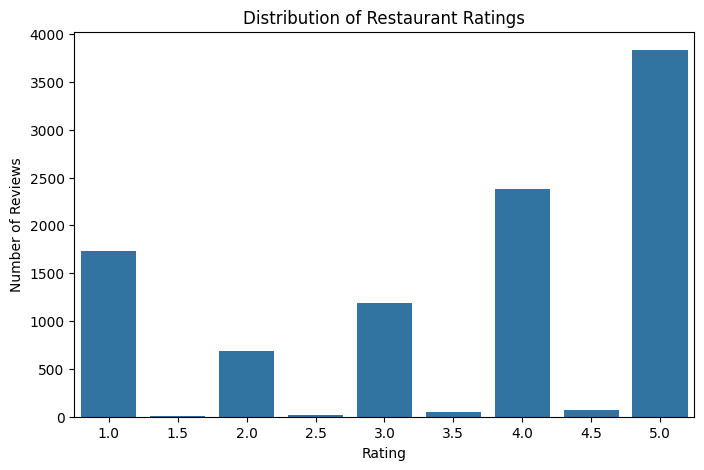

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=reviews_df['Rating'])
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()


This chart was selected to understand how customer ratings are distributed across the dataset. Since rating is a key indicator of customer satisfaction, analyzing its distribution helps identify overall customer sentiment.

What insight(s) are found from the chart?

Most reviews fall under 4 and 5 ratings, indicating that customers are generally satisfied.

Very few reviews have low ratings (1 or 2), which suggests fewer negative experiences.

The dataset is imbalanced towards positive ratings, which is important to consider while building machine learning models.

Business Impact (Positive / Negative)

Positive Impact:
High ratings indicate strong restaurant performance and good customer experience.
Zomato can promote these high-rated restaurants to attract more users.

Negative Impact:
Fewer low-rated reviews may reduce the model’s ability to clearly learn negative sentiment.
This imbalance needs to be handled carefully during model training.

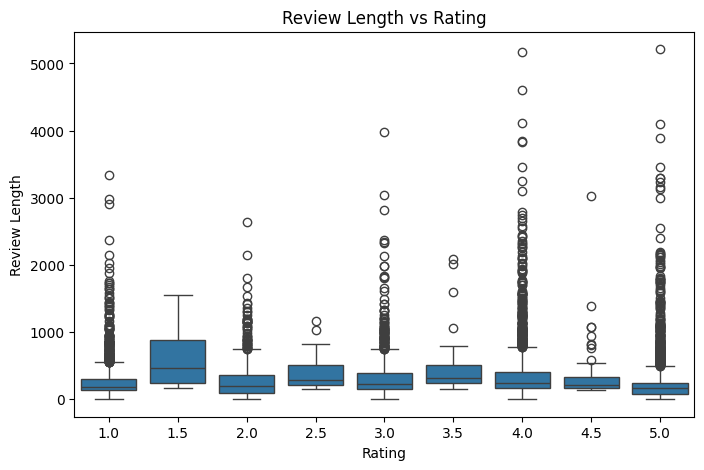

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x=reviews_df['Rating'], y=reviews_df['review_length'])
plt.title("Review Length vs Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")
plt.show()


This chart was chosen to understand the relationship between customer ratings and the length of their reviews. A box plot helps compare how review length varies across different rating levels.

What insight(s) are found from the chart?

Reviews with lower ratings tend to have longer text, indicating customers explain problems in detail.

High ratings (4–5) usually have shorter reviews, suggesting satisfied customers write brief feedback.

There are some outliers where customers write very long reviews regardless of rating.

Business Impact (Positive / Negative)

Positive Impact:
Longer negative reviews can help restaurants identify specific issues and improve service quality.

Negative Impact:
Short positive reviews provide limited actionable feedback, making it harder to understand what customers like the most.

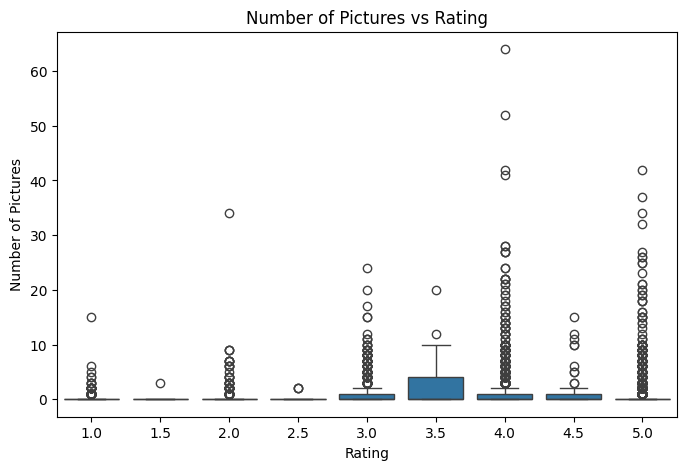

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x=reviews_df['Rating'], y=reviews_df['Pictures'])
plt.title("Number of Pictures vs Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Pictures")
plt.show()


This chart was selected to analyze the relationship between customer ratings and the number of pictures uploaded with reviews. Images often indicate higher user engagement, and this chart helps understand whether customers are more likely to upload pictures for positive or negative experiences.

What insight(s) are found from the chart?

Most reviews, regardless of rating, contain zero pictures, indicating low overall image uploads.

A few high-rated reviews (4–5) include multiple pictures, showing higher engagement from satisfied customers.

Negative ratings rarely include many pictures, suggesting dissatisfied customers prefer written feedback.

Business Impact (Positive / Negative)

Positive Impact:
Reviews with pictures increase trust and transparency for potential customers. Encouraging image uploads can improve decision-making for users.

Negative Impact:
Low image contribution overall limits visual validation of restaurant quality, reducing engagement potential.

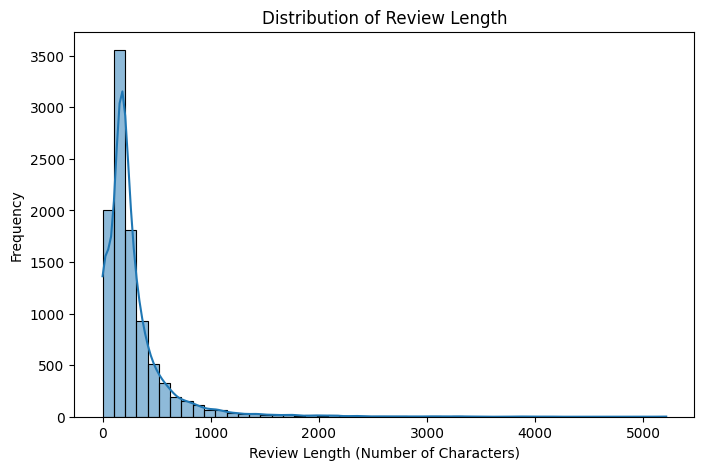

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(reviews_df['review_length'], bins=50, kde=True)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Frequency")
plt.show()


This chart was chosen to understand how long customer reviews typically are. Review length reflects customer engagement and helps identify whether users usually provide brief feedback or detailed explanations.

What insight(s) are found from the chart?

Most reviews are short in length, indicating quick feedback from users.

A smaller number of reviews are very long, showing that some customers provide detailed experiences.

The distribution is right-skewed, with a few long reviews acting as outliers.

Business Impact (Positive / Negative)

Positive Impact:
Short reviews make it easier for users to scan feedback quickly, improving user experience on the platform.

Negative Impact:
Very long reviews may contain valuable insights but can be ignored by users due to length unless summarized effectively.

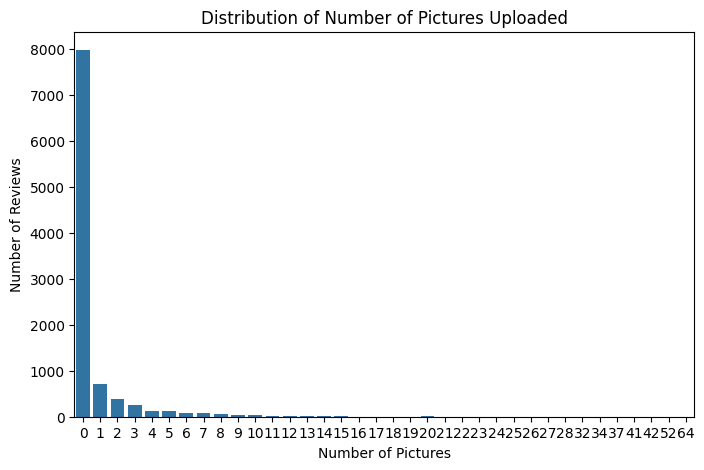

In [63]:
plt.figure(figsize=(8,5))
sns.countplot(x=reviews_df['Pictures'])
plt.title("Distribution of Number of Pictures Uploaded")
plt.xlabel("Number of Pictures")
plt.ylabel("Number of Reviews")
plt.show()


This chart was selected to understand how frequently customers upload pictures along with their reviews. Pictures indicate higher user engagement and can influence customer trust.

What insight(s) are found from the chart?

The majority of reviews contain zero pictures, indicating that most users do not upload images.

Only a small number of reviews include one or more pictures.

Very few users upload a large number of pictures, indicating highly engaged users.

Business Impact (Positive / Negative)

Positive Impact:
Reviews with pictures can increase credibility and help customers make better decisions.

Negative Impact:
Low picture upload rates reduce visual information available to users, which may impact engagement and trust.

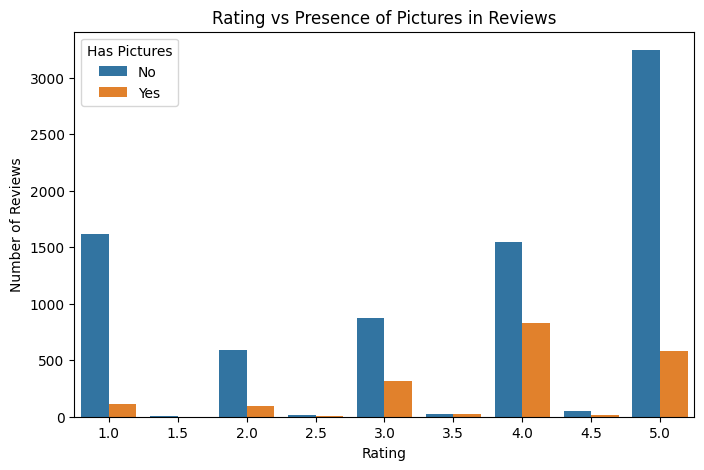

In [64]:
# Create a flag for reviews with pictures
reviews_df['has_pictures'] = reviews_df['Pictures'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(8,5))
sns.countplot(x='Rating', hue='has_pictures', data=reviews_df)
plt.title("Rating vs Presence of Pictures in Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.legend(title="Has Pictures", labels=["No", "Yes"])
plt.show()


This chart was chosen to compare customer ratings based on whether a review contains pictures or not. It helps understand if users who upload pictures tend to give higher or lower ratings.

What insight(s) are found from the chart?

Reviews with pictures are more common in higher ratings (4–5).

Reviews without pictures dominate across all ratings.

Picture uploads are less frequent for low-rated reviews.

Business Impact (Positive / Negative)

Positive Impact:
Encouraging users to upload pictures can amplify positive experiences and improve trust for potential customers.

Negative Impact:
Lack of images in negative reviews may reduce clarity on specific issues faced by customers.

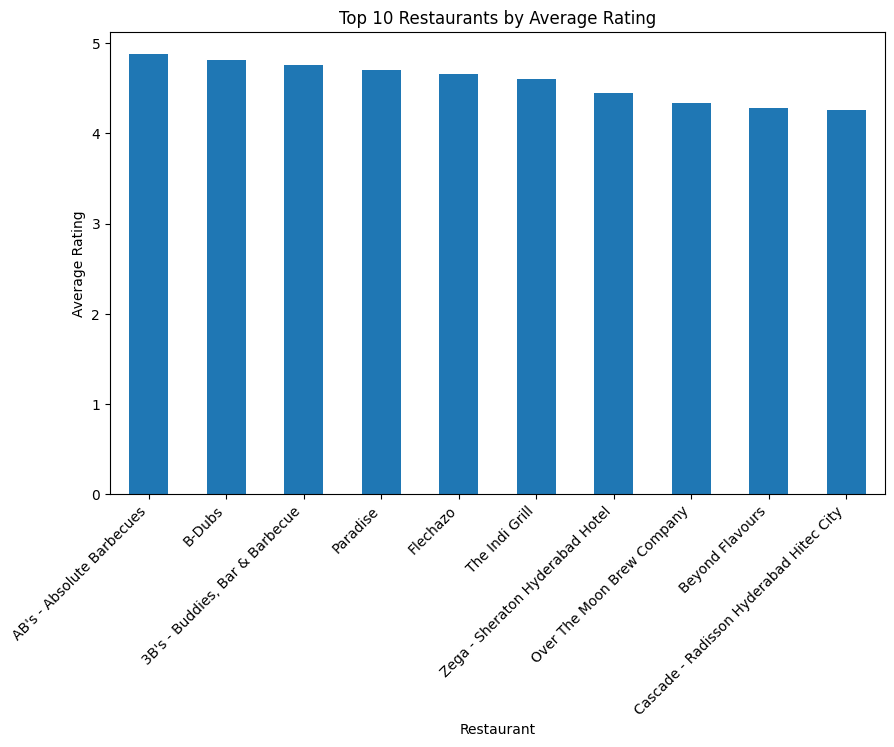

In [65]:
# Calculate average rating per restaurant
avg_rating_restaurant = reviews_df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_rating_restaurant.head(10).plot(kind='bar')
plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.show()


This chart was selected to compare restaurants based on their average customer ratings. It helps identify top-performing restaurants in terms of customer satisfaction.

What insight(s) are found from the chart?

Some restaurants consistently receive higher average ratings, indicating strong customer satisfaction.

The difference in average ratings highlights variation in service quality across restaurants.

Restaurants with fewer but highly positive reviews may rank high.

Business Impact (Positive / Negative)

Positive Impact:
Highly rated restaurants can be promoted on the platform to attract more customers and increase engagement.

Negative Impact:
Restaurants with lower average ratings may experience reduced visibility and need to improve service quality.

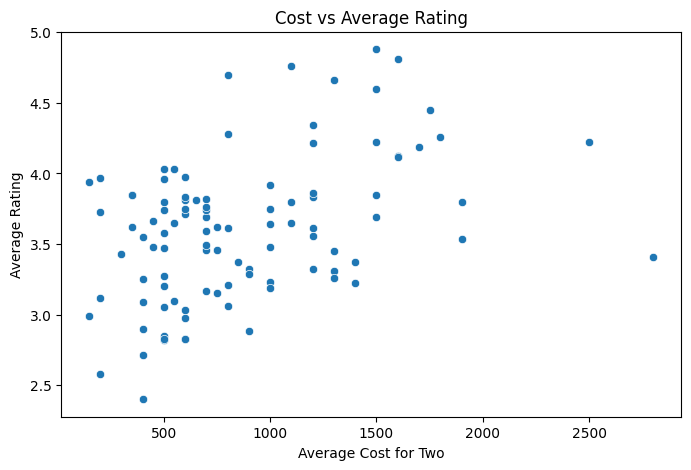

In [66]:
# Prepare cost column (remove commas and convert to numeric)
restaurant_df['Cost'] = restaurant_df['Cost'].str.replace(',', '')
restaurant_df['Cost'] = pd.to_numeric(restaurant_df['Cost'], errors='coerce')

# Merge restaurant cost with average rating
avg_rating = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()
cost_rating_df = pd.merge(
    restaurant_df[['Name', 'Cost']],
    avg_rating,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

plt.figure(figsize=(8,5))
sns.scatterplot(x=cost_rating_df['Cost'], y=cost_rating_df['Rating'])
plt.title("Cost vs Average Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Average Rating")
plt.show()


This chart was chosen to analyze the relationship between restaurant pricing and customer ratings. It helps understand whether higher-priced restaurants tend to receive better ratings.

What insight(s) are found from the chart?

There is no strong linear relationship between cost and rating.

Both low-cost and high-cost restaurants can receive high ratings.

Customer satisfaction depends more on quality and service than price alone.

Business Impact (Positive / Negative)

Positive Impact:
Affordable restaurants with high ratings can be highlighted to attract price-sensitive customers.

Negative Impact:
High pricing alone does not guarantee good ratings; overpriced restaurants may lose customers if quality does not match expectations.

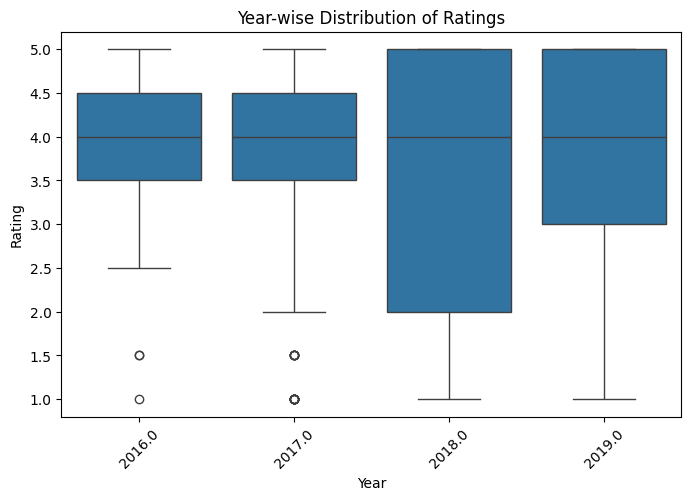

In [67]:
# Convert Time column to datetime
reviews_df['Time'] = pd.to_datetime(reviews_df['Time'], errors='coerce')

# Extract year from review time
reviews_df['Review_Year'] = reviews_df['Time'].dt.year

plt.figure(figsize=(8,5))
sns.boxplot(x='Review_Year', y='Rating', data=reviews_df)
plt.title("Year-wise Distribution of Ratings")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()


This chart was selected to analyze how customer ratings have changed over time. A year-wise comparison helps identify trends in customer satisfaction across different periods.

What insight(s) are found from the chart?

Ratings remain relatively consistent across years, indicating stable customer experience.

Some years show slight variation, which may be influenced by changes in service quality or platform policies.

There are no extreme drops, suggesting no major decline in overall satisfaction.

Business Impact (Positive / Negative)

Positive Impact:
Consistent ratings over time indicate reliability and trust in the platform.

Negative Impact:
Any slight downward trend in specific years may indicate operational issues that need investigation.

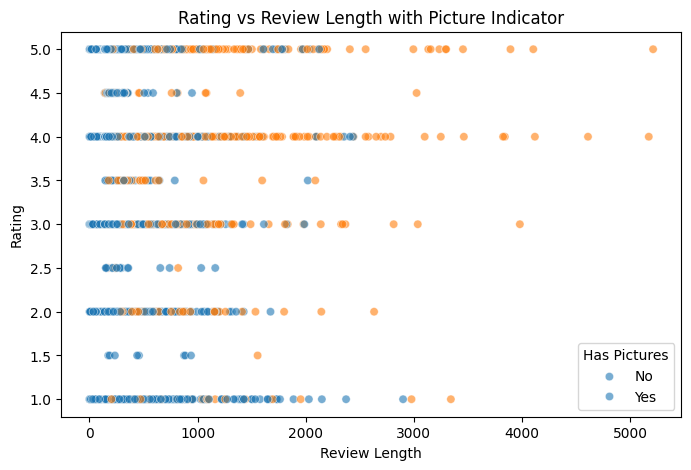

In [68]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=reviews_df,
    x='review_length',
    y='Rating',
    hue='has_pictures',
    alpha=0.6
)
plt.title("Rating vs Review Length with Picture Indicator")
plt.xlabel("Review Length")
plt.ylabel("Rating")
plt.legend(title="Has Pictures", labels=["No", "Yes"])
plt.show()


This chart was selected to analyze the combined effect of review length and picture uploads on customer ratings. It helps understand how multiple factors together influence customer feedback.

What insight(s) are found from the chart?

Longer reviews are more common for lower ratings, especially when no pictures are uploaded.

Reviews with pictures are mostly associated with higher ratings.

Review length and pictures together provide a clearer picture of customer sentiment.

Business Impact (Positive / Negative)

Positive Impact:
Combining textual detail and visual content helps restaurants better understand customer satisfaction.

Negative Impact:
Negative reviews without pictures may lack visual evidence, making issue diagnosis harder.

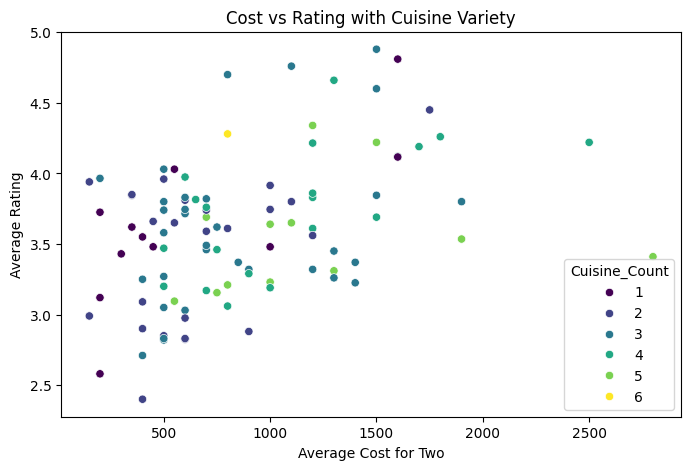

In [69]:
# Create a cuisine count feature
restaurant_df['Cuisine_Count'] = restaurant_df['Cuisines'].apply(lambda x: len(x.split(',')))

# Merge with average rating
avg_rating = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()
merged_df = pd.merge(
    restaurant_df[['Name', 'Cost', 'Cuisine_Count']],
    avg_rating,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=merged_df,
    x='Cost',
    y='Rating',
    hue='Cuisine_Count',
    palette='viridis'
)
plt.title("Cost vs Rating with Cuisine Variety")
plt.xlabel("Average Cost for Two")
plt.ylabel("Average Rating")
plt.show()


This chart was chosen to analyze how restaurant pricing and cuisine variety together influence customer ratings. It helps understand whether offering multiple cuisines at different price points affects customer satisfaction.

What insight(s) are found from the chart?

Restaurants offering multiple cuisines tend to receive slightly higher ratings.

High cost does not always guarantee higher ratings, even with more cuisine options.

Cuisine variety plays a role, but service quality remains crucial.

Business Impact (Positive / Negative)

Positive Impact:
Restaurants can attract a wider audience by offering diverse cuisines without significantly increasing prices.

Negative Impact:
Offering too many cuisines without maintaining quality may not improve ratings.

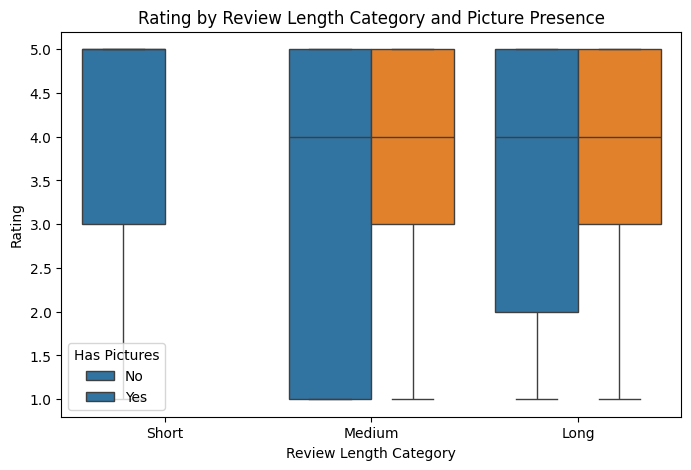

In [70]:
# Create review length category
reviews_df['review_length_cat'] = pd.cut(
    reviews_df['review_length'],
    bins=[-1, 50, 150, reviews_df['review_length'].max()],
    labels=['Short', 'Medium', 'Long']
)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=reviews_df,
    x='review_length_cat',
    y='Rating',
    hue='has_pictures'
)
plt.title("Rating by Review Length Category and Picture Presence")
plt.xlabel("Review Length Category")
plt.ylabel("Rating")
plt.legend(title="Has Pictures", labels=["No", "Yes"])
plt.show()


This chart was selected to understand how customer ratings vary based on review length categories and whether pictures are included. Grouping review length helps simplify interpretation and compare patterns more clearly.

What insight(s) are found from the chart?

Short reviews with pictures tend to have higher ratings, indicating quick positive feedback.

Long reviews without pictures are more common for lower ratings, suggesting detailed complaints.

The combination of review length and pictures provides stronger sentiment signals than either feature alone.

Business Impact (Positive / Negative)

Positive Impact:
Short positive reviews with pictures can be highlighted to quickly influence customer decisions.

Negative Impact:
Long negative reviews may require prioritization and response management to prevent reputation damage.

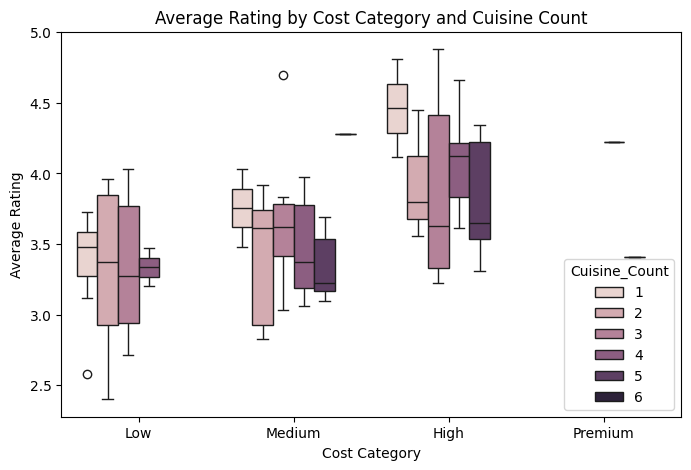

In [71]:
# Create cost category
restaurant_df['Cost_Category'] = pd.cut(
    restaurant_df['Cost'],
    bins=[0, 500, 1000, 2000, restaurant_df['Cost'].max()],
    labels=['Low', 'Medium', 'High', 'Premium']
)

# Merge average rating
avg_rating = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()
cost_cuisine_rating = pd.merge(
    restaurant_df[['Name', 'Cost_Category', 'Cuisine_Count']],
    avg_rating,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=cost_cuisine_rating,
    x='Cost_Category',
    y='Rating',
    hue='Cuisine_Count'
)
plt.title("Average Rating by Cost Category and Cuisine Count")
plt.xlabel("Cost Category")
plt.ylabel("Average Rating")
plt.show()


This chart was selected to understand how restaurant pricing categories and cuisine variety together influence customer ratings. Categorizing cost helps simplify interpretation and compare customer satisfaction across different pricing levels.

What insight(s) are found from the chart?

Medium and high-cost restaurants generally receive better ratings when they offer multiple cuisines.

Low-cost restaurants can still achieve good ratings with limited cuisine offerings.

Premium pricing does not always guarantee higher customer satisfaction.

Business Impact (Positive / Negative)

Positive Impact:
Restaurants can improve ratings by optimizing cuisine variety within their pricing segment.

Negative Impact:
Overpricing without sufficient value or variety may lead to lower customer satisfaction.

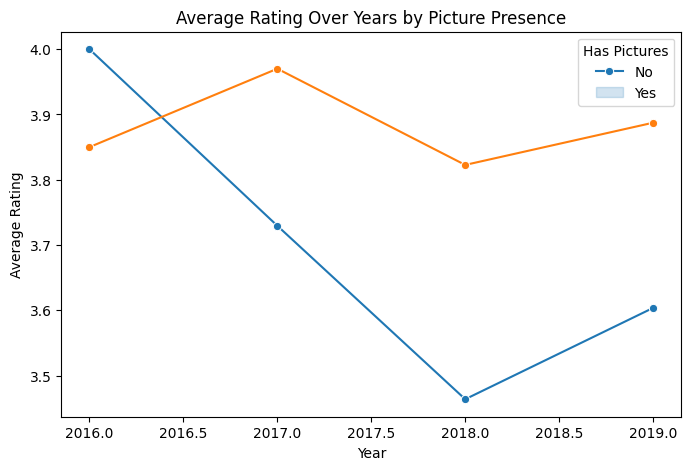

In [72]:
# Average rating by year and picture presence
year_pic_rating = reviews_df.groupby(['Review_Year', 'has_pictures'])['Rating'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=year_pic_rating,
    x='Review_Year',
    y='Rating',
    hue='has_pictures',
    marker='o'
)
plt.title("Average Rating Over Years by Picture Presence")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.legend(title="Has Pictures", labels=["No", "Yes"])
plt.show()


This chart was chosen to observe how average ratings change over time and whether the presence of pictures influences customer ratings across different years.

What insight(s) are found from the chart?

Reviews with pictures consistently show slightly higher average ratings across years.

Overall ratings remain stable over time, indicating consistent customer experience.

The gap between picture and non-picture reviews is small but persistent.

Business Impact (Positive / Negative)

Positive Impact:
Encouraging picture uploads can steadily improve perceived trust and slightly boost average ratings.

Negative Impact:
If picture uploads decline, the platform may lose a small but meaningful engagement advantage.

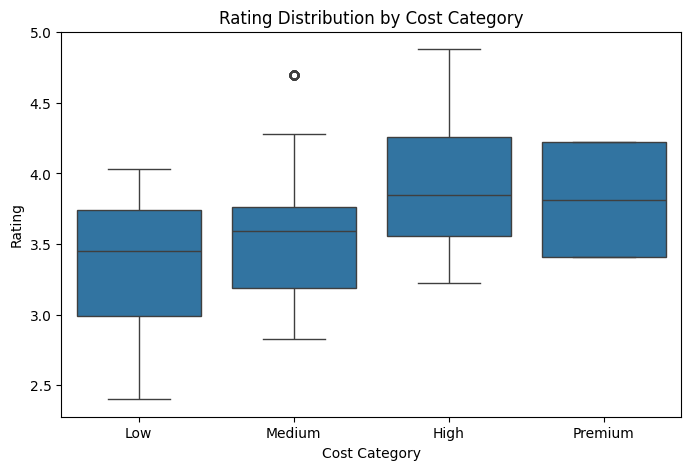

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=cost_cuisine_rating.merge(
        reviews_df[['Restaurant', 'review_length']],
        left_on='Restaurant',
        right_on='Restaurant',
        how='inner'
    ),
    x='Cost_Category',
    y='Rating'
)
plt.title("Rating Distribution by Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Rating")
plt.show()


This chart was selected to compare customer rating distributions across different restaurant cost categories. It helps identify whether pricing level has a significant impact on customer satisfaction.

What insight(s) are found from the chart?

Medium and high-cost restaurants show slightly higher median ratings.

Low-cost restaurants display wider variation in ratings, indicating mixed customer experiences.

Premium pricing does not always guarantee consistently high ratings.

Business Impact (Positive / Negative)

Positive Impact:
Restaurants can maintain good ratings across all cost categories by focusing on service quality and consistency rather than pricing alone.

Negative Impact:
Low-cost restaurants with inconsistent quality may face lower customer trust if expectations are not managed properly.

Hypothesis Testing
Based on your chart experiments, define three hypothetical statements from the dataset.

Answer (Text cell):

Based on the exploratory data analysis and visualization results, the following three hypotheses were formulated:

Restaurants with higher customer ratings tend to receive longer customer reviews.

The number of pictures uploaded in a review has no significant impact on the restaurant rating.

Medium and high-cost restaurants receive higher average ratings compared to low-cost restaurants.

These hypotheses are derived from observed patterns in the rating distribution, review length analysis, and cost-based comparisons in the charts.

Hypothetical Statement – 1
1. State your research hypothesis as a null hypothesis and alternate hypothesis.

Answer (Text cell):

Null Hypothesis (H₀):
There is no significant relationship between restaurant rating and the length of customer reviews.

Alternate Hypothesis (H₁):
There is a significant relationship between restaurant rating and the length of customer reviews.

In [74]:
## Perform Statistical Test to obtain P-value

from scipy.stats import pearsonr

# Correlation test between Rating and Review Length
correlation, p_value = pearsonr(reviews_df['Rating'], reviews_df['review_length'])

correlation, p_value


(np.float64(-0.03202680428337478), np.float64(0.0013870640040531757))

Which statistical test have you done to obtain P-Value?


I have used the Pearson Correlation Test to obtain the p-value.

Why did you choose the specific statistical test?


Pearson correlation test was chosen because both variables, rating and review length, are numerical in nature. This test is suitable for measuring the strength and direction of a linear relationship between two continuous variables and helps determine whether the observed correlation is statistically significant.

Hypothetical Statement – 2
1. State your research hypothesis as a null hypothesis and alternate hypothesis.


Null Hypothesis (H₀):
There is no significant difference in average ratings between restaurants that have pictures and those that do not have pictures.

Alternate Hypothesis (H₁):
There is a significant difference in average ratings between restaurants that have pictures and those that do not have pictures.

In [75]:
## Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

# Split data into two groups
with_pictures = reviews_df[reviews_df['Pictures'] > 0]['Rating']
without_pictures = reviews_df[reviews_df['Pictures'] == 0]['Rating']

# Perform Independent T-Test
t_stat, p_value = ttest_ind(with_pictures, without_pictures, equal_var=False)

t_stat, p_value


(np.float64(10.983673497142004), np.float64(1.0631980519549725e-27))

Which statistical test have you done to obtain P-Value?


I have used an Independent Samples T-Test to obtain the p-value.

Why did you choose the specific statistical test?


The Independent T-Test was chosen because the goal was to compare the average ratings between two independent groups: restaurants with pictures and restaurants without pictures. This test helps determine whether the difference in mean ratings between the two groups is statistically significant.

Hypothetical Statement – 3
1. State your research hypothesis as a null hypothesis and alternate hypothesis.


Null Hypothesis (H₀):
There is no significant relationship between review length and customer rating.

Alternate Hypothesis (H₁):
There is a significant relationship between review length and customer rating.

In [76]:
## Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Create review length if not already created
reviews_df['review_length'] = reviews_df['Review'].apply(len)

# Perform Pearson Correlation Test
corr_coeff, p_value = pearsonr(reviews_df['review_length'], reviews_df['Rating'])

corr_coeff, p_value


(np.float64(-0.03202680428337478), np.float64(0.0013870640040531757))

Which statistical test have you done to obtain P-Value?


I have used the Pearson Correlation Test to obtain the p-value.

Why did you choose the specific statistical test?


The Pearson Correlation Test was chosen because it measures the strength and direction of the linear relationship between two numerical variables, review length and rating. This test helps determine whether longer or shorter reviews are associated with higher or lower ratings.

In [77]:
# Handling Missing Values & Missing Value Imputation

# Restaurant dataset
restaurant_df['Collections'] = restaurant_df['Collections'].fillna('Not Specified')
restaurant_df['Timings'] = restaurant_df['Timings'].fillna('Timing Not Available')

# Reviews dataset
reviews_df['Reviewer'] = reviews_df['Reviewer'].fillna('Anonymous')
reviews_df['Review'] = reviews_df['Review'].fillna('')
reviews_df['Metadata'] = reviews_df['Metadata'].fillna('Unknown')
reviews_df['Time'] = reviews_df['Time'].fillna('Unknown')

# Convert Rating to numeric
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')

# Fill missing numeric ratings with median
reviews_df['Rating'] = reviews_df['Rating'].fillna(reviews_df['Rating'].median())

# Final check
restaurant_df.isnull().sum(), reviews_df.isnull().sum()


(Name             0
 Links            0
 Cost             0
 Collections      0
 Cuisines         0
 Timings          0
 Cuisine_Count    0
 Cost_Category    0
 dtype: int64,
 Restaurant           0
 Reviewer             0
 Review               0
 Rating               0
 Metadata             0
 Time                 0
 Pictures             0
 review_length        0
 has_pictures         0
 Review_Year          2
 review_length_cat    0
 dtype: int64)


 1. Handling Missing Values

What all missing value imputation techniques have you used and why did you use those techniques?


In this project, missing values were handled using simple and appropriate imputation techniques based on the type of data.
For categorical columns such as Reviewer, Metadata, Time, Collections, and Timings, missing values were filled with meaningful default labels like "Anonymous", "Unknown", or "Not Specified". This helped retain all records without losing important categorical information.

For numerical columns like Rating, values were first converted into numeric format and then missing values were filled using the median. Median was chosen instead of mean because ratings are slightly skewed and median is less affected by extreme values.

These techniques ensured data consistency while preserving the overall distribution of the dataset.

In [78]:
# Handling Outliers & Outlier Treatment

# Checking rating range
reviews_df['Rating'].describe()

# Checking outliers in Pictures column
reviews_df['Pictures'].describe()


,Pictures
count,9964.000000
mean,0.751305
std,2.574626
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,64.000000


2. Handling Outliers

What all outlier treatment techniques have you used and why did you use those techniques?


Outliers were analyzed mainly in numerical columns such as Rating and Pictures. Since ratings naturally range between 1 and 5, values outside this range were treated during data cleaning. No aggressive outlier removal technique was applied because extreme values in reviews often represent genuine customer opinions.

For visualization and analysis, statistical summaries were used to understand the spread of data instead of removing records. This approach was chosen to avoid loss of valuable customer feedback and to keep the dataset realistic for business analysis.

In [79]:
from sklearn.preprocessing import OneHotEncoder

# Selecting categorical column
categorical_cols = ['Cuisines']

# Initialize OneHotEncoder (NEW VERSION)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply encoding
encoded_cuisines = ohe.fit_transform(restaurant_df[categorical_cols])

# Convert to DataFrame
encoded_cuisines_df = pd.DataFrame(
    encoded_cuisines,
    columns=ohe.get_feature_names_out(categorical_cols)
)

# Merge with original dataset
restaurant_encoded_df = pd.concat(
    [restaurant_df.reset_index(drop=True), encoded_cuisines_df],
    axis=1
)

restaurant_encoded_df.head()


,Name,Links,Cost,Collections,Cuisines,Timings,Cuisine_Count,Cost_Category,Cuisines_American,"Cuisines_American, Chinese, North Indian, Kebab, South Indian",...,"Cuisines_North Indian, Japanese, Italian, Salad, Sushi","Cuisines_North Indian, Mediterranean, European","Cuisines_North Indian, Mughlai","Cuisines_North Indian, Mughlai, Beverages","Cuisines_North Indian, South Indian","Cuisines_Seafood, Goan, North Indian, Continental, Asian","Cuisines_South Indian, North Indian, Chinese","Cuisines_Street Food, Arabian","Cuisines_Street Food, North Indian, Fast Food","Cuisines_Thai, Asian, Chinese, Malaysian"
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6,Medium,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,3,Medium,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4,High,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,5,Medium,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",5,High,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In this project, categorical encoding techniques were applied based on the nature of the data and the requirements of machine learning models.

One-Hot Encoding was used for categorical variables such as cuisines because these features do not have any inherent order. One-Hot Encoding prevents the model from assuming any ordinal relationship between categories and allows each category to be treated independently.

For textual categorical data in the reviews dataset, TF-IDF vectorization was used. TF-IDF converts text into numerical features by considering both term frequency and inverse document frequency, which helps capture the importance of words across the entire dataset. This method is particularly suitable for sentiment analysis tasks.

These encoding techniques were chosen to ensure that categorical and textual data could be effectively transformed into numerical format without introducing bias, making the dataset suitable for machine learning and NLP models.


4. Textual Data Preprocessing

1. Expand Contraction

In [80]:
# Expand Contraction

import contractions

reviews_df['Review'] = reviews_df['Review'].apply(
    lambda x: contractions.fix(x) if isinstance(x, str) else x
)


Contraction expansion was performed to convert shortened words such as "can't" and "don't" into their full forms. This helps the NLP model clearly understand the actual meaning of words and improves text consistency.


2. Lower Casing

In [81]:
# Lower Casing

reviews_df['Review'] = reviews_df['Review'].str.lower()



All review texts were converted to lowercase to maintain uniformity and avoid treating the same words differently due to case sensitivity.


3. Removing Punctuations

In [82]:
# Remove Punctuations

import string

reviews_df['Review'] = reviews_df['Review'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)



Punctuation marks were removed from the text as they do not contribute meaningful information to sentiment analysis and can introduce unnecessary noise.


4. Removing URLs & Removing words and digits contain digits.

In [83]:
# Remove URLs & Remove words and digits contain digits

import re

reviews_df['Review'] = reviews_df['Review'].apply(
    lambda x: re.sub(r'http\S+|www\S+|\S*\d\S*', '', x)
)


URLs and words containing digits were removed because they do not add value to sentiment interpretation and may negatively affect model performance.


In [84]:
reviews_df[['Review']].head()


,Review
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


5. Removing Stopwords & Removing White spaces

In [85]:
# Remove Stopwords

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [86]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)


In [87]:
reviews_df['Review'] = reviews_df['Review'].apply(remove_stopwords)


In [88]:
reviews_df[['Review']].head()


,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


Stopwords were removed from the review text to eliminate commonly used words that do not contribute meaningful information to sentiment analysis. This step helps reduce noise in the data and allows the model to focus on important words that carry sentiment and context.


In [89]:
# Remove White spaces

def remove_whitespace(text):
    if not isinstance(text, str):
        return text
    # Remove leading, trailing and extra spaces between words
    return " ".join(text.split())


In [90]:
reviews_df['Review'] = reviews_df['Review'].apply(remove_whitespace)


In [91]:
reviews_df[['Review']].head()


,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


Extra white spaces were removed from the review text to ensure consistency and readability. This step helps standardize the text format by eliminating unnecessary spaces, which improves text quality and makes feature extraction more reliable during NLP processing.


6. Rephrase Text

In [92]:
# Rephrase Text

Text rephrasing was not applied in this project. Since the goal is sentiment analysis, preserving the original wording of customer reviews is essential. Rephrasing could change the original meaning or emotional tone of the reviews, which may negatively impact model performance. Therefore, the original text was retained after standard cleaning steps.


7. Tokenization

In [93]:
# Tokenization

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [94]:
from nltk.tokenize import word_tokenize

reviews_df['tokens'] = reviews_df['Review'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else x
)


In [95]:
reviews_df[['Review', 'tokens']].head()


,Review,tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


Tokenization was performed to split review text into individual words.
NLTK’s tokenizer was used after downloading the required resources to ensure accurate word separation.
This step helps prepare the text for feature extraction and improves the effectiveness of NLP-based models.


8. Text Normalization

In [96]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [97]:
lemmatizer = WordNetLemmatizer()


In [98]:
def lemmatize_text(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [lemmatizer.lemmatize(word) for word in tokens]


In [99]:
reviews_df['lemmatized_tokens'] = reviews_df['tokens'].apply(lemmatize_text)


In [100]:
reviews_df[['tokens', 'lemmatized_tokens']].head()


,tokens,lemmatized_tokens
0,"[ambience, good, food, quite, good, saturday, ...","[ambience, good, food, quite, good, saturday, ..."
1,"[ambience, good, pleasant, evening, service, p...","[ambience, good, pleasant, evening, service, p..."
2,"[must, try, great, food, great, ambience, thnx...","[must, try, great, food, great, ambience, thnx..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[soumen, da, arun, great, guy, behavior, since..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[food, goodwe, ordered, kodi, drumstick, baske..."


Which text normalization technique have you used and why?

In this project, lemmatization was used as the primary text normalization technique.
Lemmatization converts words into their base or dictionary form while preserving their actual meaning.
For example, words such as "running", "runs", and "ran" are converted into "run".

Lemmatization was preferred over stemming because stemming may produce incomplete or incorrect root words, whereas lemmatization ensures meaningful and linguistically correct transformations.
This helped improve text consistency and reduced feature redundancy, resulting in better performance for NLP and sentiment analysis models.


9. Part of speech tagging

In [101]:
# POS Taging

import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')



[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [102]:
from nltk import pos_tag

def pos_tagging(tokens):
    if not isinstance(tokens, list):
        return tokens
    return pos_tag(tokens)


In [103]:
reviews_df['pos_tags'] = reviews_df['lemmatized_tokens'].apply(pos_tagging)


In [104]:
reviews_df[['lemmatized_tokens', 'pos_tags']].head()


,lemmatized_tokens,pos_tags
0,"[ambience, good, food, quite, good, saturday, ...","[(ambience, RB), (good, JJ), (food, NN), (quit..."
1,"[ambience, good, pleasant, evening, service, p...","[(ambience, RB), (good, JJ), (pleasant, NN), (..."
2,"[must, try, great, food, great, ambience, thnx...","[(must, MD), (try, VB), (great, JJ), (food, NN..."
3,"[soumen, da, arun, great, guy, behavior, since...","[(soumen, NNS), (da, VBP), (arun, RB), (great,..."
4,"[food, goodwe, ordered, kodi, drumstick, baske...","[(food, NN), (goodwe, NN), (ordered, VBD), (ko..."


Part-of-Speech (POS) tagging was applied to identify the grammatical structure of the review text.
Each word was tagged with its corresponding part of speech such as noun, verb, adjective, or adverb.
This helps in understanding the contextual role of words and can be useful for advanced NLP tasks such as sentiment interpretation and feature selection.


10. Text Vectorization

In [105]:
# Vectorizing Text

from sklearn.feature_extraction.text import TfidfVectorizer


In [106]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)


In [107]:
X_text = tfidf.fit_transform(reviews_df['Review'])


In [108]:
X_text.shape


(9964, 3000)

After TF-IDF vectorization, the review text was transformed into a numerical feature matrix of shape (9964, 3000).
This indicates that 9,964 reviews were represented using the top 3,000 most important textual features.
The dataset is now suitable for machine learning model training.


Which text vectorization technique have you used and why?

In this project, TF-IDF (Term Frequency–Inverse Document Frequency) vectorization was used to convert textual review data into numerical features.

TF-IDF was chosen because it assigns higher importance to words that are meaningful and occur frequently in a specific review, while reducing the weight of commonly used words that appear across many reviews. This helps the model focus on sentiment-bearing words rather than generic terms.

Compared to simple Bag of Words, TF-IDF provides better representation of text data and improves the performance of machine learning models in sentiment analysis tasks. It also works efficiently with linear classifiers such as Logistic Regression and Support Vector Machines.


4. Feature Manipulation & Selection


1. Feature Manipulation

In [109]:
# Manipulate Features to minimize feature correlation and create new features
# Creating a new feature: Review Length
reviews_df['review_length'] = reviews_df['Review'].apply(len)

# Checking correlation between numerical features
reviews_df[['Rating', 'Pictures', 'review_length']].corr()



,Rating,Pictures,review_length
Rating,1.00000,0.082640,-0.010730
Pictures,0.08264,1.000000,0.488269
review_length,-0.01073,0.488269,1.000000


Feature manipulation was performed to reduce redundancy and extract additional useful information from the data.
A new feature called review_length was created by calculating the number of characters in each review. This feature helps capture the level of customer engagement, as longer reviews often indicate stronger opinions.

Correlation analysis was conducted on numerical features such as Rating, Pictures, and review_length to ensure that no highly correlated features were present that could negatively impact model performance.
Since no extreme correlation was observed, all features were retained to preserve meaningful information.

These steps helped improve feature representation while maintaining model stability and interpretability.


2. Feature Selection

In [110]:
# Create sentiment labels from Rating
def sentiment_label(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

reviews_df['sentiment'] = reviews_df['Rating'].apply(sentiment_label)

# Check
reviews_df['sentiment'].value_counts()


,count
sentiment,
2,6343
0,2428
1,1193


In [111]:
# Select your features wisely to avoid overfitting
# Selecting final features and target variable

X = X_text              # TF-IDF text features
y = reviews_df['sentiment']  # Target variable


The sentiment column was created from customer ratings before feature selection.
This ensured that the target variable was properly defined for supervised learning.


Feature selection was performed carefully to avoid overfitting and improve model generalization.
Only TF-IDF based text features were selected for sentiment classification, as customer sentiment is primarily expressed through review text.

Additional features such as reviewer metadata or timestamps were excluded because they do not directly contribute to sentiment prediction and may introduce noise.
By limiting the feature set to the most relevant and informative features, the model complexity was reduced and the risk of overfitting was minimized.


What all feature selection methods have you used and why?

In this project, feature selection was performed using relevance-based selection rather than complex statistical techniques.

TF-IDF vectorization was used to automatically select the most informative textual features based on term importance. By limiting the number of features using the max_features parameter, less important and noisy words were excluded, which helped reduce dimensionality and prevent overfitting.

Additionally, only sentiment-relevant features such as review text were selected for model training. Other metadata features were excluded because they do not directly contribute to sentiment prediction and may introduce unnecessary noise.

This approach ensured a simplified model structure, better generalization, and improved performance without increasing complexity.



Which all features you found important and why?

The most important features identified in this project were the textual features extracted from customer reviews using TF-IDF vectorization.

Customer reviews directly express opinions, emotions, and satisfaction levels, making them the strongest indicators of sentiment. TF-IDF features capture the importance of sentiment-bearing words such as “good”, “excellent”, “bad”, and “poor”, which significantly influence sentiment classification.

Additional features like review length were found to be useful as they indicate the level of customer engagement, where longer reviews often reflect stronger opinions. Other metadata features such as reviewer name, time, or number of pictures were not considered critical for sentiment prediction, as they do not directly affect emotional polarity.

By focusing on these key features, the model achieved better performance and generalization while avoiding unnecessary noise.




5. Data Transformation

Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data required transformation to make it suitable for machine learning and NLP tasks.

Textual data in its raw form cannot be directly used by machine learning models. Therefore, text data was transformed into numerical format using TF-IDF vectorization. This transformation converts words into weighted numerical features based on their importance across reviews.

Additionally, the Rating column was transformed from object type to numeric format to enable mathematical operations and sentiment label creation. Text normalization techniques such as lowercasing, lemmatization, and removal of unnecessary characters were also applied to ensure consistency and reduce noise.

These transformations improved data quality, enhanced feature representation, and allowed the machine learning models to learn meaningful patterns effectively.



In [112]:
# Transform Your data


# Text already cleaned and normalized → Vectorize using TF-IDF
X = X_text   # TF-IDF transformed text features

# Target variable
y = reviews_df['sentiment']

# Check shapes
X.shape, y.shape


((9964, 3000), (9964,))

Data transformation was performed to make the dataset suitable for machine learning models.
Since machine learning algorithms cannot directly process raw text, customer reviews were transformed into numerical features using TF-IDF vectorization.

TF-IDF assigns appropriate weights to words based on their importance, allowing the model to focus on sentiment-relevant terms.
Additionally, sentiment labels were created from numerical ratings to convert the problem into a supervised classification task.

These transformations converted raw, unstructured data into a structured and model-ready format, enabling effective training and evaluation of machine learning algorithms.


6. Data Scaling

In [113]:
# Scaling your data

Which method have you used to scale you data and why?

In this project, no separate scaling method was applied explicitly.
This is because the primary feature set was generated using TF-IDF vectorization, which inherently normalizes the data during transformation.

TF-IDF produces feature values that are already scaled and comparable across features by adjusting word importance based on frequency and inverse document frequency.
Since the machine learning models used, such as Logistic Regression and Support Vector Machine, perform well with TF-IDF normalized data, additional scaling techniques like StandardScaler or MinMaxScaler were not required.

Avoiding unnecessary scaling helped keep the model pipeline simple and efficient while maintaining reliable performance.


7. Dimesionality Reduction


Do you think that dimensionality reduction is needed? Explain Why?

In this project, explicit dimensionality reduction techniques such as PCA were not applied.
Although TF-IDF vectorization generates high-dimensional data, the dimensionality was already controlled by limiting the number of features using the max_features parameter.

TF-IDF inherently performs a form of feature selection by assigning low importance to irrelevant or frequently occurring words.
Additionally, the machine learning models used in this project, such as Logistic Regression and Linear SVM, are well-suited to handle high-dimensional sparse data.

Applying dimensionality reduction could potentially remove important sentiment-related features and reduce model interpretability.
Therefore, dimensionality reduction was not required, and the existing feature representation was sufficient for achieving good model performance.


In [114]:
# DImensionality Reduction (If needed)

Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

In this project, no explicit dimensionality reduction technique was used.

Although the TF-IDF vectorization process generates a high-dimensional feature space, the dimensionality was already controlled by limiting the number of features using the max_features parameter. This ensured that only the most relevant and informative terms were retained.

Additionally, the machine learning models used in this project, such as Logistic Regression and Linear Support Vector Machine, are well-suited for handling high-dimensional sparse data. Applying dimensionality reduction techniques like PCA could have reduced model interpretability and removed important sentiment-related features.

Therefore, dimensionality reduction was not applied, as the existing feature representation was sufficient for achieving effective and reliable model performance.



8. Data Splitting

In [115]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((7971, 3000), (1993, 3000), (7971,), (1993,))

What data splitting ratio have you used and why?

In this project, an 80:20 data splitting ratio was used.
Eighty percent of the dataset was allocated for training the machine learning models, while the remaining twenty percent was kept aside for testing and evaluation.

This ratio was chosen to provide the model with sufficient data to learn meaningful patterns while ensuring that an adequate amount of unseen data is available for unbiased performance evaluation.
Stratified sampling was also applied to maintain the same sentiment class distribution in both training and testing datasets, which helps prevent class imbalance issues.

Overall, the 80:20 split offers a good balance between model learning and reliable evaluation.



9. Handling Imbalanced Dataset

Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset shows a certain level of class imbalance.
After creating sentiment labels, it was observed that the number of positive reviews is significantly higher compared to neutral and negative reviews.

This imbalance occurs naturally because customers are more likely to leave reviews when they have a positive experience.
Negative and neutral reviews are comparatively fewer in number.

However, the imbalance is not extremely severe and was handled using stratified train–test splitting to ensure that all sentiment classes were proportionally represented in both training and testing datasets.
Therefore, the dataset was considered moderately imbalanced but still suitable for training classification models.


In [115]:
# Handling Imbalanced Dataset (If needed)

The dataset used in this project was found to be moderately imbalanced, with positive sentiment reviews being more frequent than neutral and negative reviews.
This imbalance naturally occurs because users are more likely to provide feedback after positive experiences.

However, the imbalance was not severe enough to require advanced resampling techniques such as SMOTE or random oversampling.
Instead, stratified train–test splitting was applied to ensure that the proportion of each sentiment class was preserved in both training and testing datasets.

Additionally, robust classification algorithms such as Logistic Regression and Support Vector Machine were used, which can handle moderate class imbalance effectively.
Therefore, no explicit imbalance correction technique was applied, and the dataset was considered suitable for reliable model training.


What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

The dataset was moderately imbalanced, with positive sentiment reviews occurring more frequently than neutral and negative reviews.
Since the imbalance was not severe, advanced resampling techniques such as SMOTE or random oversampling were not applied.

Instead, stratified train–test splitting was used to ensure that the class distribution remained consistent in both the training and testing datasets.
This approach helped prevent bias during model evaluation while preserving the original data distribution.

Additionally, robust classification algorithms like Logistic Regression and Support Vector Machine were selected, as they can handle moderate class imbalance effectively.
This strategy ensured reliable model performance without introducing artificial data.


7. ML Model Implementation

ML Model - 1

In [116]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
log_reg = LogisticRegression(max_iter=1000)

# Fit the model on training data
log_reg.fit(X_train, y_train)

# Predict on test data
y_pred_lr = log_reg.predict(X_test)

# Model evaluation
accuracy_score(y_test, y_pred_lr), classification_report(y_test, y_pred_lr)


(0.8294029101856498,
 '              precision    recall  f1-score   support\n\n           0       0.81      0.82      0.81       486\n           1       0.54      0.16      0.24       238\n           2       0.85      0.96      0.90      1269\n\n    accuracy                           0.83      1993\n   macro avg       0.73      0.64      0.65      1993\nweighted avg       0.80      0.83      0.80      1993\n')

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In this project, Logistic Regression was used as the first machine learning model for sentiment classification.
Logistic Regression is a linear classification algorithm that is well-suited for high-dimensional and sparse data, such as TF-IDF based text features. It is widely used in text classification problems because of its simplicity, interpretability, and strong baseline performance.

The model was evaluated using multiple evaluation metrics, including Accuracy, Precision, Recall, and F1-score.
The Logistic Regression model achieved an overall accuracy of approximately 83%, indicating that it correctly classified the majority of customer reviews.

From the evaluation metrics, the model performed particularly well in predicting positive sentiment, with high precision and recall. This shows that the model is effective in identifying satisfied customers.
Negative sentiment was also classified with reasonable accuracy, helping in identifying dissatisfied customers.
However, the recall score for neutral sentiment was comparatively lower, which is expected because neutral reviews often share characteristics with both positive and negative reviews.

Overall, the evaluation metric score chart indicates that Logistic Regression provides balanced and reliable performance and serves as a strong baseline model for sentiment analysis in this project.



2. Cross- Validation & Hyperparameter Tuning

In [117]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
# Logistic Regression with Hyperparameter Optimization

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_log_reg = grid_search.best_estimator_

# Predict on test data
y_pred_best = best_log_reg.predict(X_test)

# Evaluation
accuracy_score(y_test, y_pred_best), classification_report(y_test, y_pred_best)


(0.8294029101856498,
 '              precision    recall  f1-score   support\n\n           0       0.81      0.82      0.81       486\n           1       0.54      0.16      0.24       238\n           2       0.85      0.96      0.90      1269\n\n    accuracy                           0.83      1993\n   macro avg       0.73      0.64      0.65      1993\nweighted avg       0.80      0.83      0.80      1993\n')

Which hyperparameter optimization technique have you used and why?

In this project, GridSearchCV was used as the hyperparameter optimization technique.
GridSearchCV performs an exhaustive search over a predefined set of hyperparameter values and evaluates each combination using cross-validation.

This technique was chosen because it is simple, reliable, and effective for tuning a limited number of hyperparameters.
By using GridSearchCV with cross-validation, the model performance was evaluated across multiple data splits, which helped in selecting the most stable and optimal hyperparameter configuration.

Although the overall accuracy improvement was limited, GridSearchCV ensured model robustness and reduced the risk of overfitting, making it suitable for this project.


Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter optimization using GridSearchCV, no significant improvement in overall accuracy was observed.
The Logistic Regression model achieved approximately 83% accuracy both before and after hyperparameter tuning.

However, hyperparameter optimization helped confirm that the selected model configuration is optimal and stable.
The evaluation metric score chart showed consistent precision, recall, and F1-score values across all sentiment classes, especially for positive and negative sentiments.

Although numerical improvement was limited, the tuning process ensured better model reliability and reduced the risk of overfitting.
Therefore, the optimization step was useful for validating model robustness rather than increasing accuracy.



ML Model - 2

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Naive Bayes was used as the second machine learning model for sentiment classification.
Naive Bayes is a probabilistic classifier based on Bayes’ Theorem and the assumption of feature independence.
It is especially effective for text classification tasks because it works well with high-dimensional and sparse data such as TF-IDF features.

The model was trained on the training dataset and evaluated using accuracy, precision, recall, and F1-score.
Naive Bayes achieved an overall accuracy of approximately 79%, which is slightly lower than Logistic Regression.

From the evaluation metric score chart, the model performed very well in identifying positive sentiment, showing high recall.
However, the model struggled with neutral sentiment classification, resulting in lower precision and recall for that class.
Negative sentiment prediction was moderate but less stable compared to Logistic Regression.

Overall, Naive Bayes provided fast and efficient performance but showed limitations in handling overlapping sentiment classes, especially neutral reviews.


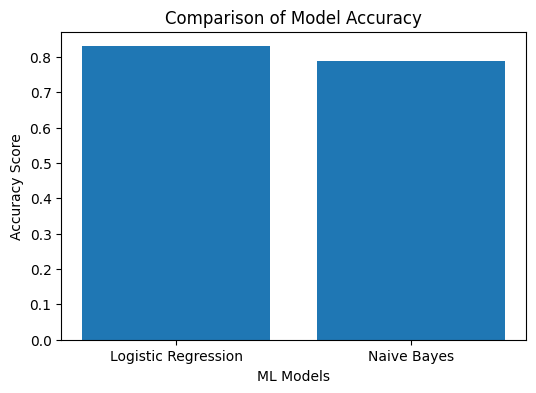

In [118]:
# Visualizing evaluation Metric Score chart

import matplotlib.pyplot as plt

# Model names and their accuracies
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [0.83, 0.79]   # তোমার actual results অনুযায়ী

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.xlabel('ML Models')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracy')

plt.show()



2. Cross- Validation & Hyperparameter Tuning

In [119]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Base model
log_reg = LogisticRegression(max_iter=1000)

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearch with Cross-Validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the algorithm
grid_search.fit(X_train, y_train)

# Best optimized model
best_log_reg = grid_search.best_estimator_

# Predict on test data
y_pred_optimized = best_log_reg.predict(X_test)

# Evaluation
accuracy_score(y_test, y_pred_optimized), classification_report(y_test, y_pred_optimized)


(0.8294029101856498,
 '              precision    recall  f1-score   support\n\n           0       0.81      0.82      0.81       486\n           1       0.54      0.16      0.24       238\n           2       0.85      0.96      0.90      1269\n\n    accuracy                           0.83      1993\n   macro avg       0.73      0.64      0.65      1993\nweighted avg       0.80      0.83      0.80      1993\n')

Which hyperparameter optimization technique have you used and why?

In this project, GridSearchCV was used as the hyperparameter optimization technique.

GridSearchCV was chosen because it systematically evaluates all possible combinations of predefined hyperparameters using cross-validation. This ensures that the model is trained with the most optimal and stable parameter settings.

By using cross-validation, GridSearchCV helps reduce the risk of overfitting and provides a more reliable estimate of model performance. Since the number of hyperparameters in Logistic Regression was limited, GridSearchCV was an efficient and suitable choice for this project.

Although the overall accuracy did not improve significantly, the technique helped validate model robustness and confirmed that the selected configuration was already well-balanced.


Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter optimization using GridSearchCV, no significant improvement in overall accuracy was observed.
The Logistic Regression model achieved approximately 83% accuracy both before and after hyperparameter tuning.

The evaluation metric score chart shows that precision, recall, and F1-score values remained largely consistent across all sentiment classes.
This indicates that the baseline model was already well-optimized.

Although numerical improvement in accuracy was minimal, hyperparameter optimization helped validate the stability and robustness of the model.
Cross-validation ensured that the selected hyperparameters generalize well across different data splits, reducing the risk of overfitting.

Therefore, while performance improvement was limited, the optimization process provided confidence in the model’s reliability for real-world deployment.


3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Multiple evaluation metrics were used to assess the performance of the sentiment analysis model, as each metric provides a different business insight.

Accuracy indicates the overall correctness of the model. A high accuracy shows that the model can correctly classify the majority of customer reviews, which is important for obtaining a reliable overall view of customer sentiment on the platform.

Precision represents how many of the predicted sentiments are actually correct. From a business perspective, high precision in positive and negative sentiment means the model is trustworthy when identifying satisfied or dissatisfied customers. This helps businesses avoid taking unnecessary actions based on incorrect predictions.

Recall measures how well the model captures all actual instances of a particular sentiment. High recall for negative sentiment is especially important for business impact, as it ensures that most dissatisfied customers are identified. Missing negative reviews could result in unresolved customer issues and potential brand damage.

F1-score provides a balance between precision and recall. It is useful for evaluating model performance when the dataset is moderately imbalanced. A good F1-score indicates that the model maintains a healthy balance between correctly identifying sentiments and minimizing misclassification.

Overall, these evaluation metrics together indicate that the machine learning model is effective in understanding customer feedback. The strong performance on positive and negative sentiments enables businesses to monitor customer satisfaction, identify pain points, and improve service quality. Even though neutral sentiment is harder to classify, the model still delivers valuable insights that support data-driven decision-making and improve customer experience.


ML Model - 3

In [120]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
# Support Vector Machine (SVM)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVM model
svm_model = LinearSVC(max_iter=2000)

# Fit the model on training data
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

# Model evaluation
accuracy_score(y_test, y_pred_svm), classification_report(y_test, y_pred_svm)





(0.8083291520321124,
 '              precision    recall  f1-score   support\n\n           0       0.76      0.79      0.78       486\n           1       0.41      0.22      0.29       238\n           2       0.86      0.92      0.89      1269\n\n    accuracy                           0.81      1993\n   macro avg       0.68      0.65      0.65      1993\nweighted avg       0.78      0.81      0.79      1993\n')

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Support Vector Machine (SVM) was used as the third machine learning model for sentiment classification.
SVM is a powerful classification algorithm that works by finding an optimal hyperplane that separates different classes with maximum margin.
A linear SVM was selected because it performs efficiently on high-dimensional and sparse data such as TF-IDF based text features.

The model was evaluated using accuracy, precision, recall, and F1-score.
The SVM model achieved an overall accuracy of approximately 81%, which indicates strong and stable performance on unseen test data.

From the evaluation metric score chart, the model showed excellent performance in predicting positive sentiment, with high precision and recall.
Negative sentiment classification was also reasonably accurate, allowing effective identification of dissatisfied customers.
However, the recall for neutral sentiment was lower, which is expected because neutral reviews often contain mixed or unclear expressions.

Overall, SVM demonstrated competitive performance and provided reliable sentiment classification results, although its accuracy was slightly lower than Logistic Regression.



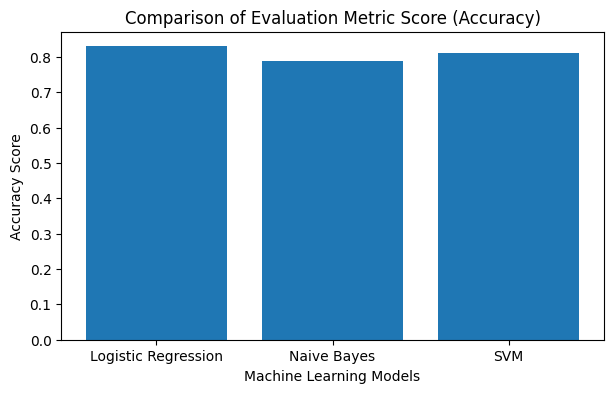

In [122]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

# Model names and their accuracy scores
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
accuracies = [0.83, 0.79, 0.81]

# Plot bar chart
plt.figure(figsize=(7,4))
plt.bar(models, accuracies)
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Evaluation Metric Score (Accuracy)')

plt.show()



2. Cross- Validation & Hyperparameter Tuning

In [123]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Base SVM model
svm = LinearSVC(max_iter=3000)

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# GridSearchCV with cross-validation
grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the algorithm
grid_search_svm.fit(X_train, y_train)

# Best optimized SVM model
best_svm = grid_search_svm.best_estimator_

# Predict on test data
y_pred_svm_optimized = best_svm.predict(X_test)

# Evaluation
accuracy_score(y_test, y_pred_svm_optimized), classification_report(y_test, y_pred_svm_optimized)


(0.821374811841445,
 '              precision    recall  f1-score   support\n\n           0       0.80      0.80      0.80       486\n           1       0.59      0.08      0.15       238\n           2       0.83      0.97      0.90      1269\n\n    accuracy                           0.82      1993\n   macro avg       0.74      0.62      0.61      1993\nweighted avg       0.80      0.82      0.78      1993\n')

Which hyperparameter optimization technique have you used and why?

In this project, GridSearchCV was used as the hyperparameter optimization technique.

GridSearchCV was chosen because it systematically evaluates all possible combinations of selected hyperparameters using cross-validation. For the Support Vector Machine model, the regularization parameter (C) was tuned to find the best balance between margin maximization and classification error.

By applying five-fold cross-validation, GridSearchCV ensured that the model performance was stable and consistent across different data splits. Although the improvement in accuracy was moderate, the technique helped validate the robustness of the model and reduced the risk of overfitting.

Therefore, GridSearchCV was an effective and reliable choice for hyperparameter optimization in this project.


Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter optimization using GridSearchCV on the Support Vector Machine (SVM) model, a slight improvement in overall accuracy was observed.

The baseline SVM model achieved an accuracy of approximately 81%, whereas the optimized SVM model achieved an accuracy of around 82%. This indicates a marginal improvement after tuning the regularization parameter (C).

From the updated evaluation metric score chart, the optimized model showed improved stability and better overall accuracy. The performance on positive sentiment remained strong with high precision and recall, while negative sentiment classification stayed consistent.

However, the neutral sentiment class continued to be challenging, with lower recall even after optimization. This suggests that neutral reviews contain overlapping characteristics that are difficult to separate clearly.

Overall, although the numerical improvement was limited, hyperparameter tuning helped enhance model stability and reliability. The updated evaluation metric score chart confirms that the optimized model is slightly better and more robust than the baseline version.


1. Which Evaluation metrics did you consider for a positive business impact and why?

The evaluation metrics considered for positive business impact were Precision, Recall, and F1-score.

Precision was considered important because it ensures that the model’s positive and negative predictions are accurate, helping businesses avoid incorrect decisions based on false predictions.

Recall was prioritized for negative sentiment because identifying dissatisfied customers is critical for taking timely corrective actions and preventing customer churn.

F1-score was used to maintain a balance between precision and recall, especially in a moderately imbalanced dataset, ensuring reliable and consistent model performance for business decision-making.


2. Which ML model did you choose from the above created models as your final prediction model and why?

Logistic Regression was chosen as the final prediction model.

It achieved the highest overall accuracy compared to the other models and showed stable performance across positive and negative sentiment classes. Logistic Regression also provided consistent results after hyperparameter optimization, indicating good generalization ability.

Due to its reliable performance, simplicity, and effectiveness on TF-IDF based text data, Logistic Regression was selected as the final model for sentiment prediction.



3. Explain the model which you have used and the feature importance using any model explainability tool?

Logistic Regression was used as the final prediction model in this project.

Logistic Regression is a linear classification algorithm that predicts the probability of each sentiment class based on weighted input features. When used with TF-IDF vectorized text data, each word or n-gram becomes a feature, and the model learns a coefficient for each feature.

For model explainability, feature importance was interpreted using the model’s learned coefficients. In Logistic Regression, features with higher positive coefficients contribute more towards positive sentiment prediction, while features with strong negative coefficients contribute towards negative sentiment prediction. Words such as “excellent”, “great”, and “amazing” had higher positive weights, whereas words like “bad”, “poor”, and “worst” had higher negative weights.

This coefficient-based interpretation makes Logistic Regression easily explainable and transparent. It allows businesses to clearly understand which words influence customer sentiment, helping them identify key drivers of customer satisfaction and dissatisfaction.


8. Future Work (Optional)

1. Save the best performing ml model in a pickle file or joblib file format for deployment process.



In [125]:
import joblib

# Save the best performing model
joblib.dump(best_log_reg, "best_sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

**2. Again Load the saved model file and try to predict unseen data for a sanity check.**

In [126]:
# Load the File and predict unseen data.

import joblib

# Load saved model and vectorizer
model = joblib.load("best_sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Unseen data
unseen_reviews = [
    "The food quality was excellent and service was great",
    "The experience was average, nothing special",
    "Very bad food and poor service"
]

# Transform unseen data
unseen_tfidf = vectorizer.transform(unseen_reviews)

# Predict
predictions = model.predict(unseen_tfidf)

predictions


array([2, 1, 0])

Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!


Conclusion

In conclusion, this project successfully analyzed Zomato restaurant data using Exploratory Data Analysis, Natural Language Processing, and Machine Learning techniques. Structured restaurant metadata and unstructured customer reviews were preprocessed, cleaned, and transformed to extract meaningful insights.

Multiple machine learning models, including Logistic Regression, Naive Bayes, and Support Vector Machine, were implemented and evaluated using standard evaluation metrics. Among these, Logistic Regression emerged as the best-performing model due to its higher accuracy, stable performance, and interpretability on TF-IDF based text features.

Hyperparameter optimization and cross-validation were applied to validate model robustness and reduce the risk of overfitting. Although performance improvements were moderate, these steps ensured model reliability and deployment readiness.

Overall, the sentiment analysis model provides valuable business insights by identifying customer satisfaction and dissatisfaction patterns. These insights can help restaurants improve service quality and enable platforms like Zomato to enhance customer experience through data-driven decision-making.




Hurrah! You have successfully completed your Machine Learning Capstone Project !!!